### Phase vs. amplitude encoding in fronto-parietal LFP recordings (Figures 5–6)

This notebook reproduces **Figures 5 and 6** by applying the PID framework to real local-field-potential recordings from monkey prefrontal and parietal cortex during a working-memory task (GrayLab dataset, session betty).

**Workflow:**
1. Configure environment and imports.
2. Load per-trial LFP data and trial metadata.
3. Compute time-frequency coherence (multitaper wavelet, 0.1–30 Hz).
4. Estimate GC-MI between stimulus and joint amplitude / phase-difference.
5. Build shuffle-based null distribution and apply cluster statistics.
6. Compute HOI (2-edge redundancy / synergy) across channel pairs.
7. Assemble and export Figures 5 and 6.

#### 1) Environment setup

In [1]:
import os
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import jax
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import gcmi_model_nd_cd
from frites.workflow import WfStats
from hoi.core import get_mi
from mne.filter import filter_data
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from session import session_info
from tqdm import tqdm
from frites.core import copnorm_nd
import jax.numpy as jnp

/home/INT/brovelli.a/.local/lib/python3.10/site-packages/tqdm-4.67.1-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 2) Imports, matplotlib style and helper functions

`trial_to_string` zero-pads trial indices to match the per-trial `.mat` filename format. `create_generalized_surrogates` builds semi-generalized surrogates by drawing random channel and trial pairs — preserving temporal structure within each channel while breaking the stimulus–response relationship.

In [4]:
def trial_to_string(trial_no, n_max):
    trial_no = str(trial_no)
    n = len(trial_no)
    return (n_max - n) * "0" + trial_no

In [5]:
def shuffle_along_axis(a, axis):
    """Shuffle data along specified axis."""
    idx = np.random.rand(*a.shape).argsort(axis=axis)
    return np.take_along_axis(a, idx, axis=axis)


def create_generalized_surrogates(X, n_boot=10000):
    """Create semi-generalized surrogate."""
    T, R, N = X.shape  # Extract dimensions

    # Trials onsets
    t_match_on = (data.attrs["t_match_on"] - data.attrs["t_cue_on"]) / data.fsample
    t_match_on = np.round(t_match_on, 1)

    X = X.values

    # Sample trials
    count = 0
    trials_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(T),
            size=2,
            replace=False,
        )
        trials_surr += [out]
        count = count + 1
    trials_surr = np.stack(trials_surr)

    # Sample channels
    count = 0
    channels_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(R),
            size=2,
            replace=False,
        )
        channels_surr += [out]
        count = count + 1
    channels_surr = np.stack(channels_surr)

    data_surr = []
    for c_i, c_j, trial_i, trial_j in np.concatenate(
        (channels_surr, trials_surr), axis=1
    ):
        x = X[trial_i, c_i]
        y = X[trial_j, c_j]  # [..., ::-1]
        data_surr += [np.stack((x, y))]

    # Get shortest onset time for each pair of sampled trials
    onsets = []
    for t1, t2 in trials_surr:
        onsets += [min(t_match_on[t1], t_match_on[t2])]
    onsets = np.stack(onsets)

    return np.stack(data_surr), onsets

In [18]:
#sessions = np.loadtxt("sessions_betty.txt", dtype=str)

#### 3) Load trial metadata and LFP data

Load `trial_info` and `recording_info` from MATLAB files, keep only correct and stable trials, build per-trial stimulus labels, then read each trial's LFP into a `(n_trials, n_channels, n_times)` array aligned to sample onset.

In [6]:
#sessions = np.loadtxt("sessions_betty.txt", dtype=str)

#print(sys.argv)
#if len(sys.argv) > 3:
#    index = int(sys.argv[3])
#else:
#    index = 0

# session = sessions[index]
session = "090615"

In [ ]:
root = f"/Users/vinicius/data/GrayLab/betty/{session}/session01/"

save_path = f"figures/data/coherence/{session}"

if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [8]:
trial_info = {}
scipy.io.loadmat(
    os.path.join(root, "trial_info.mat"), simplify_cells=True, mdict=trial_info
)
trial_info = trial_info["trial_info"]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/vinicius/data/GrayLab/betty/090615/session01/trial_info.mat'

In [22]:
recording_info = {}
scipy.io.loadmat(
    os.path.join(root, "recording_info.mat"), simplify_cells=True, mdict=recording_info
)
recording_info = recording_info["recording_info"]

In [ ]:

# Keep only trials where the monkey responded correctly AND recording was stable AND LFP quality passed QC
task_trials = np.where(
    trial_info["behavioral_response"]
    * trial_info["stable_trials"]
    * trial_info["good_trials"]
)[0]


In [ ]:

stim = []

for trial in task_trials:
    # rule 1 = object working memory → label by image identity
    # rule 2 = spatial working memory → label by match location
    if trial_info["rule"][trial] == 1:
        stim.append(trial_info["match_image"][trial])
    else:
        stim.append(trial_info["match_location"][trial])


In [25]:
time_array = np.arange(-0.4, 1.7, 1 / recording_info["lfp_sampleingrate"])

In [26]:
n_trials, n_channels, n_times = (
    len(task_trials),
    recording_info["channel_count"],
    len(time_array),
)

In [27]:
data = np.empty((n_trials, n_channels, n_times))  # LFP data

# For each selected trial
i = 0
for trial in tqdm(task_trials):

    lfp_data = scipy.io.loadmat(
        os.path.join(root, f"betty{session}01.{trial_to_string(trial + 1, 4)}.mat")
    )["lfp_data"]

    # Beggining and ending time index for this t0
    indb = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.min()
    )
    inde = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.max()
    )
    # LFP data, dimension NtrialsxNchannelsxTime
    data[i, ...] = lfp_data[:, indb : inde + 1]

    i = i + 1

100%|████████████████████████████████| 993/993 [00:02<00:00, 362.71it/s]


#### 4) Convert to xarray and inspect channel traces

In [28]:
data = xr.DataArray(
    data,
    dims=("trials", "roi", "times"),
    coords=(
        # trial_info["match_image"][task_trials],
        stim,
        recording_info["area"],
        time_array,
    ),
    attrs={
        "t_match_on": trial_info["match_on"],
        "t_cue_on": trial_info["sample_on"],
        "fsample": recording_info["lfp_sampleingrate"],
    },
)

(-0.5, 1.7, -4.561347220428129, 18.97876915494902)

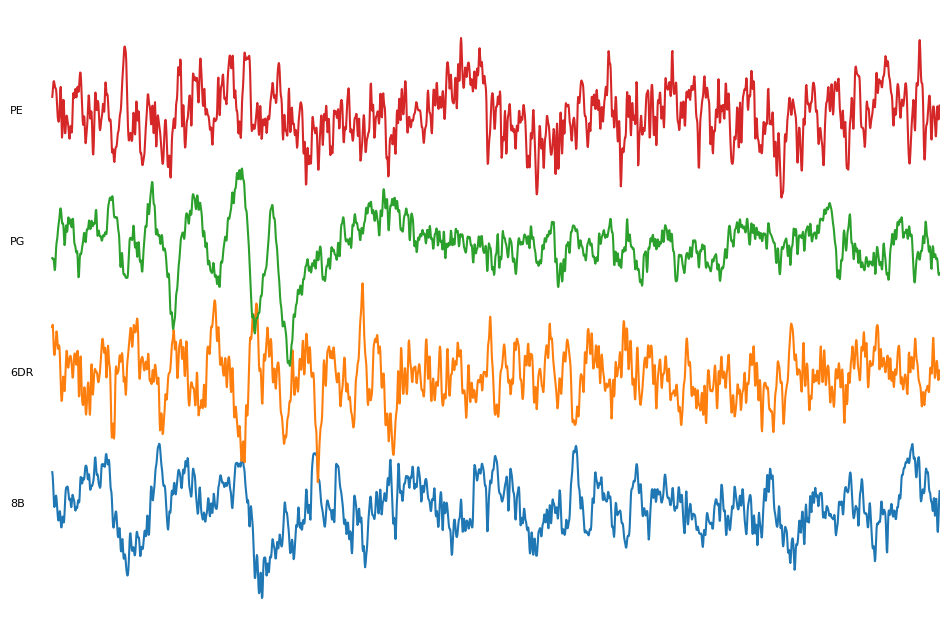

In [29]:
plt.figure(figsize=(12, 8))
zdata = (data - data.mean("times")) / data.std("times")


for i in range(data.sizes["roi"]):

    plt.plot(data.times, zdata[0, i] + (i * 5))
    plt.text(-0.5, (i * 5), zdata.roi.values[i])

plt.xlim(-0.5, 1.7)
plt.axis("off")

#### 5) Stimulus-related coherence (SRC) — pairwise MI

Compute multitaper wavelet coefficients (0.1–30 Hz) for all channel pairs. Estimate GC-MI between the joint amplitude/phase representation and the stimulus label. Build a shuffle-based null distribution (1000 permutations) and apply cluster-level correction.

In [30]:
x_s, x_t = np.triu_indices(data.sizes["roi"], 1)

In [32]:
freqs = np.linspace(0.1, 30, 50)

W = tfr_array_multitaper(
    data,
    recording_info["lfp_sampleingrate"],
    freqs,
    n_cycles=freqs / 2,
    decim=20,
    time_bandwidth=5,
    output="complex",
    verbose=True,
)

In [ ]:

# Trial-averaged cross-spectrum for each channel pair (upper triangle)
z = (W[:, x_s] * np.conj(W[:, x_t])).mean(2)

# Amplitude: copnorm makes it Gaussian for GC-MI estimation
A = np.abs(z)
A = copnorm_nd(A, axis=0)

# Unit-norm complex: 2 features (real, imag) / |z| captures phase without amplitude confound
dphi = jnp.stack((z.real, z.imag)) / np.abs(z)

# Joint representation: amplitude + 2-D phase → (3, n_pairs, n_freqs, n_times)
mv = np.concatenate((A[None], dphi))

# GC-MI between each source (A, dphi, joint) and the stimulus label Y
# mvaxis=0: features axis; traxis=1: trials axis
I_S_R1 = gcmi_model_nd_cd(
    A[None], np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=False
)

I_S_R2 = gcmi_model_nd_cd(
    dphi, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=False
)

I_S_R1_R2 = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=False
)


In [ ]:

from joblib import Parallel, delayed


def compute_shuffle(mv):
    # Random permutation of trial labels breaks stimulus–response relationship
    return gcmi_model_nd_cd(
        mv, np.random.permutation(data.trials.values), mvaxis=0, traxis=1, gcrn=True
    )


# 1000 surrogates run in parallel across 5 workers
I_S_R1_R2_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(1_000))
)


In [45]:
x = [np.asarray(I_S_R1_R2[i][None]) for i in range(len(x_s))]
y = [np.stack(I_S_R1_R2_shuffle)[:, i][:, None] for i in range(len(x_s))]

In [46]:
wf = WfStats()

p, t = wf.fit(
    x,
    y,
    inference="ffx",
    mcp="cluster",
)

p = p.squeeze()

p.min()

Definition of a non-parametric statistical workflow
    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.008792629070611466; tail=1)


0.001

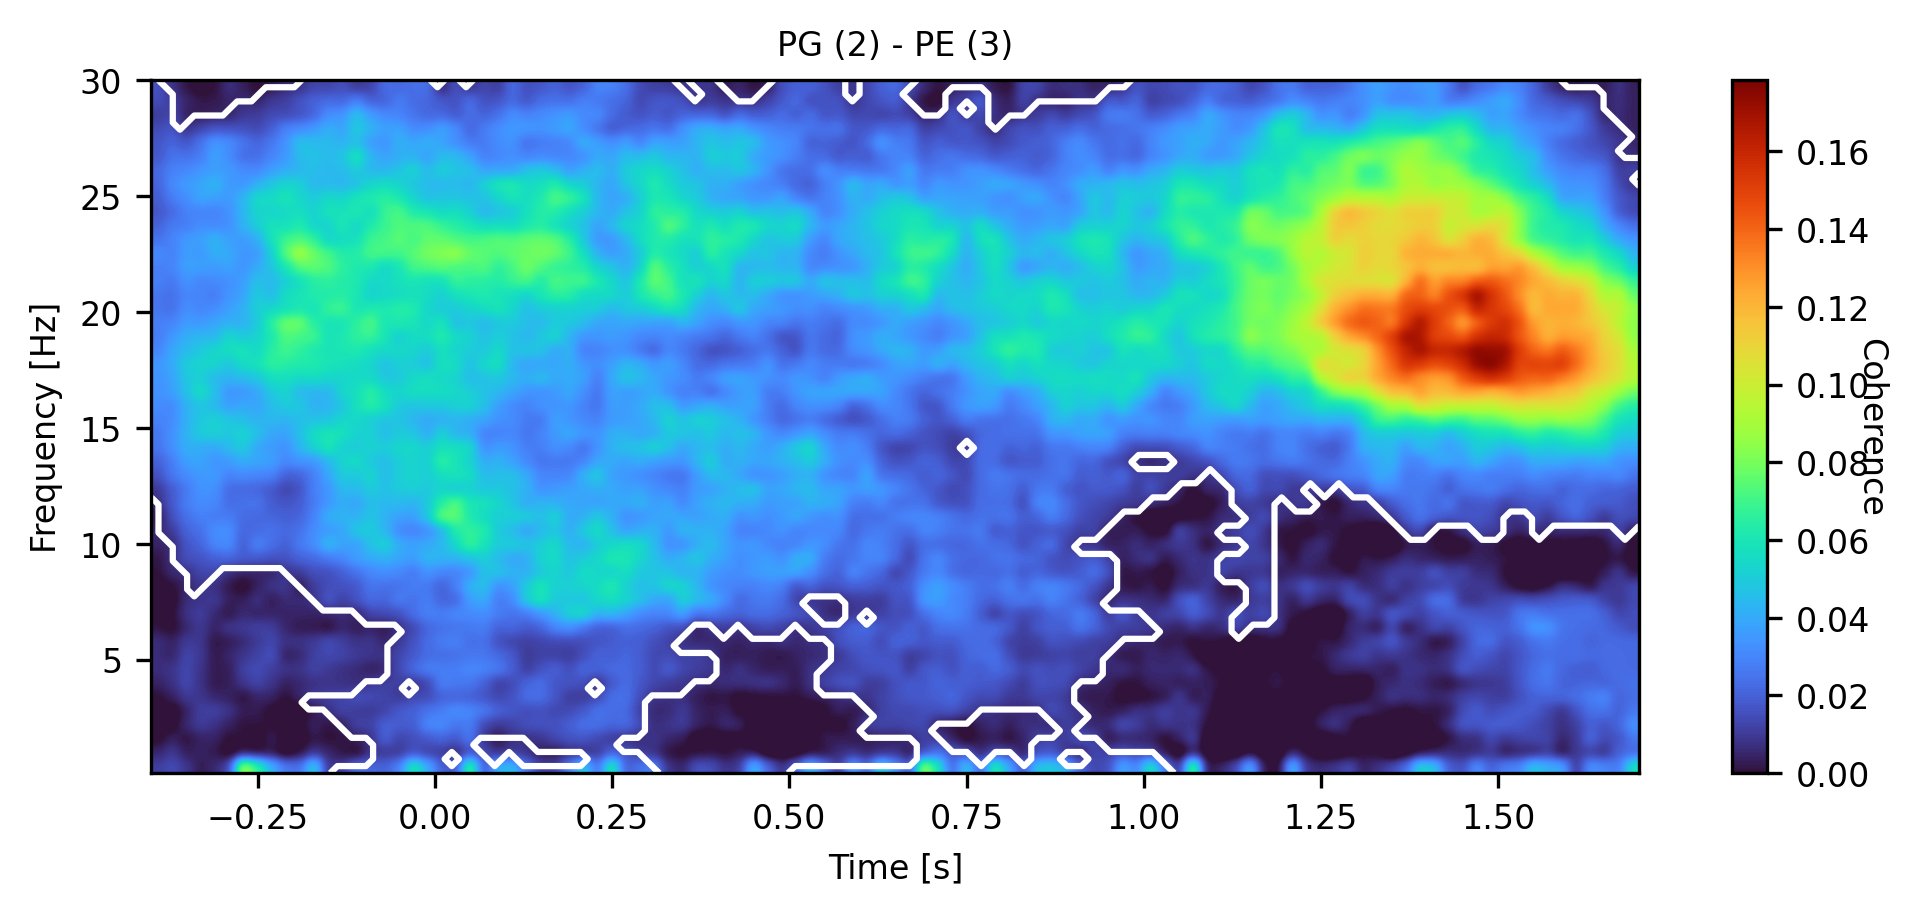

In [63]:
fig = plt.figure(num=1, clear=True, figsize=(8, 3), dpi=300)

pos = 0

for i, j in zip(x_s, x_t):

    fig = plt.figure(num=1, clear=True)

    plt.imshow(
        I_S_R1_R2[pos],
        aspect="auto",
        origin="lower",
        cmap="turbo",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
        vmin=0,
        interpolation="gaussian",
        vmax=I_S_R1_R2[pos].max(),
    )
    cbar = plt.colorbar()

    plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

    cbar.set_label("Coherence", rotation=270)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")

    plt.contour(
        (p[..., pos] <= 0.001),
        levels=[0.5],
        colors="w",
        extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    )

    plt.savefig(
        os.path.join(
            save_path,
            f"total_MI_{data.roi.values[i]}_{i} - {data.roi.values[j]}_{j}.pdf",
        )
    )

    pos = pos + 1

In [ ]:

# PID decomposition (min-redundancy / max-synergy definitions)
# Redundancy = min(I_A, I_dphi); Synergy = I_joint − max(I_A, I_dphi)
red = np.minimum(I_S_R1, I_S_R2)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)


#### 6) Figure 5 — pairwise unique information (amplitude vs. phase)

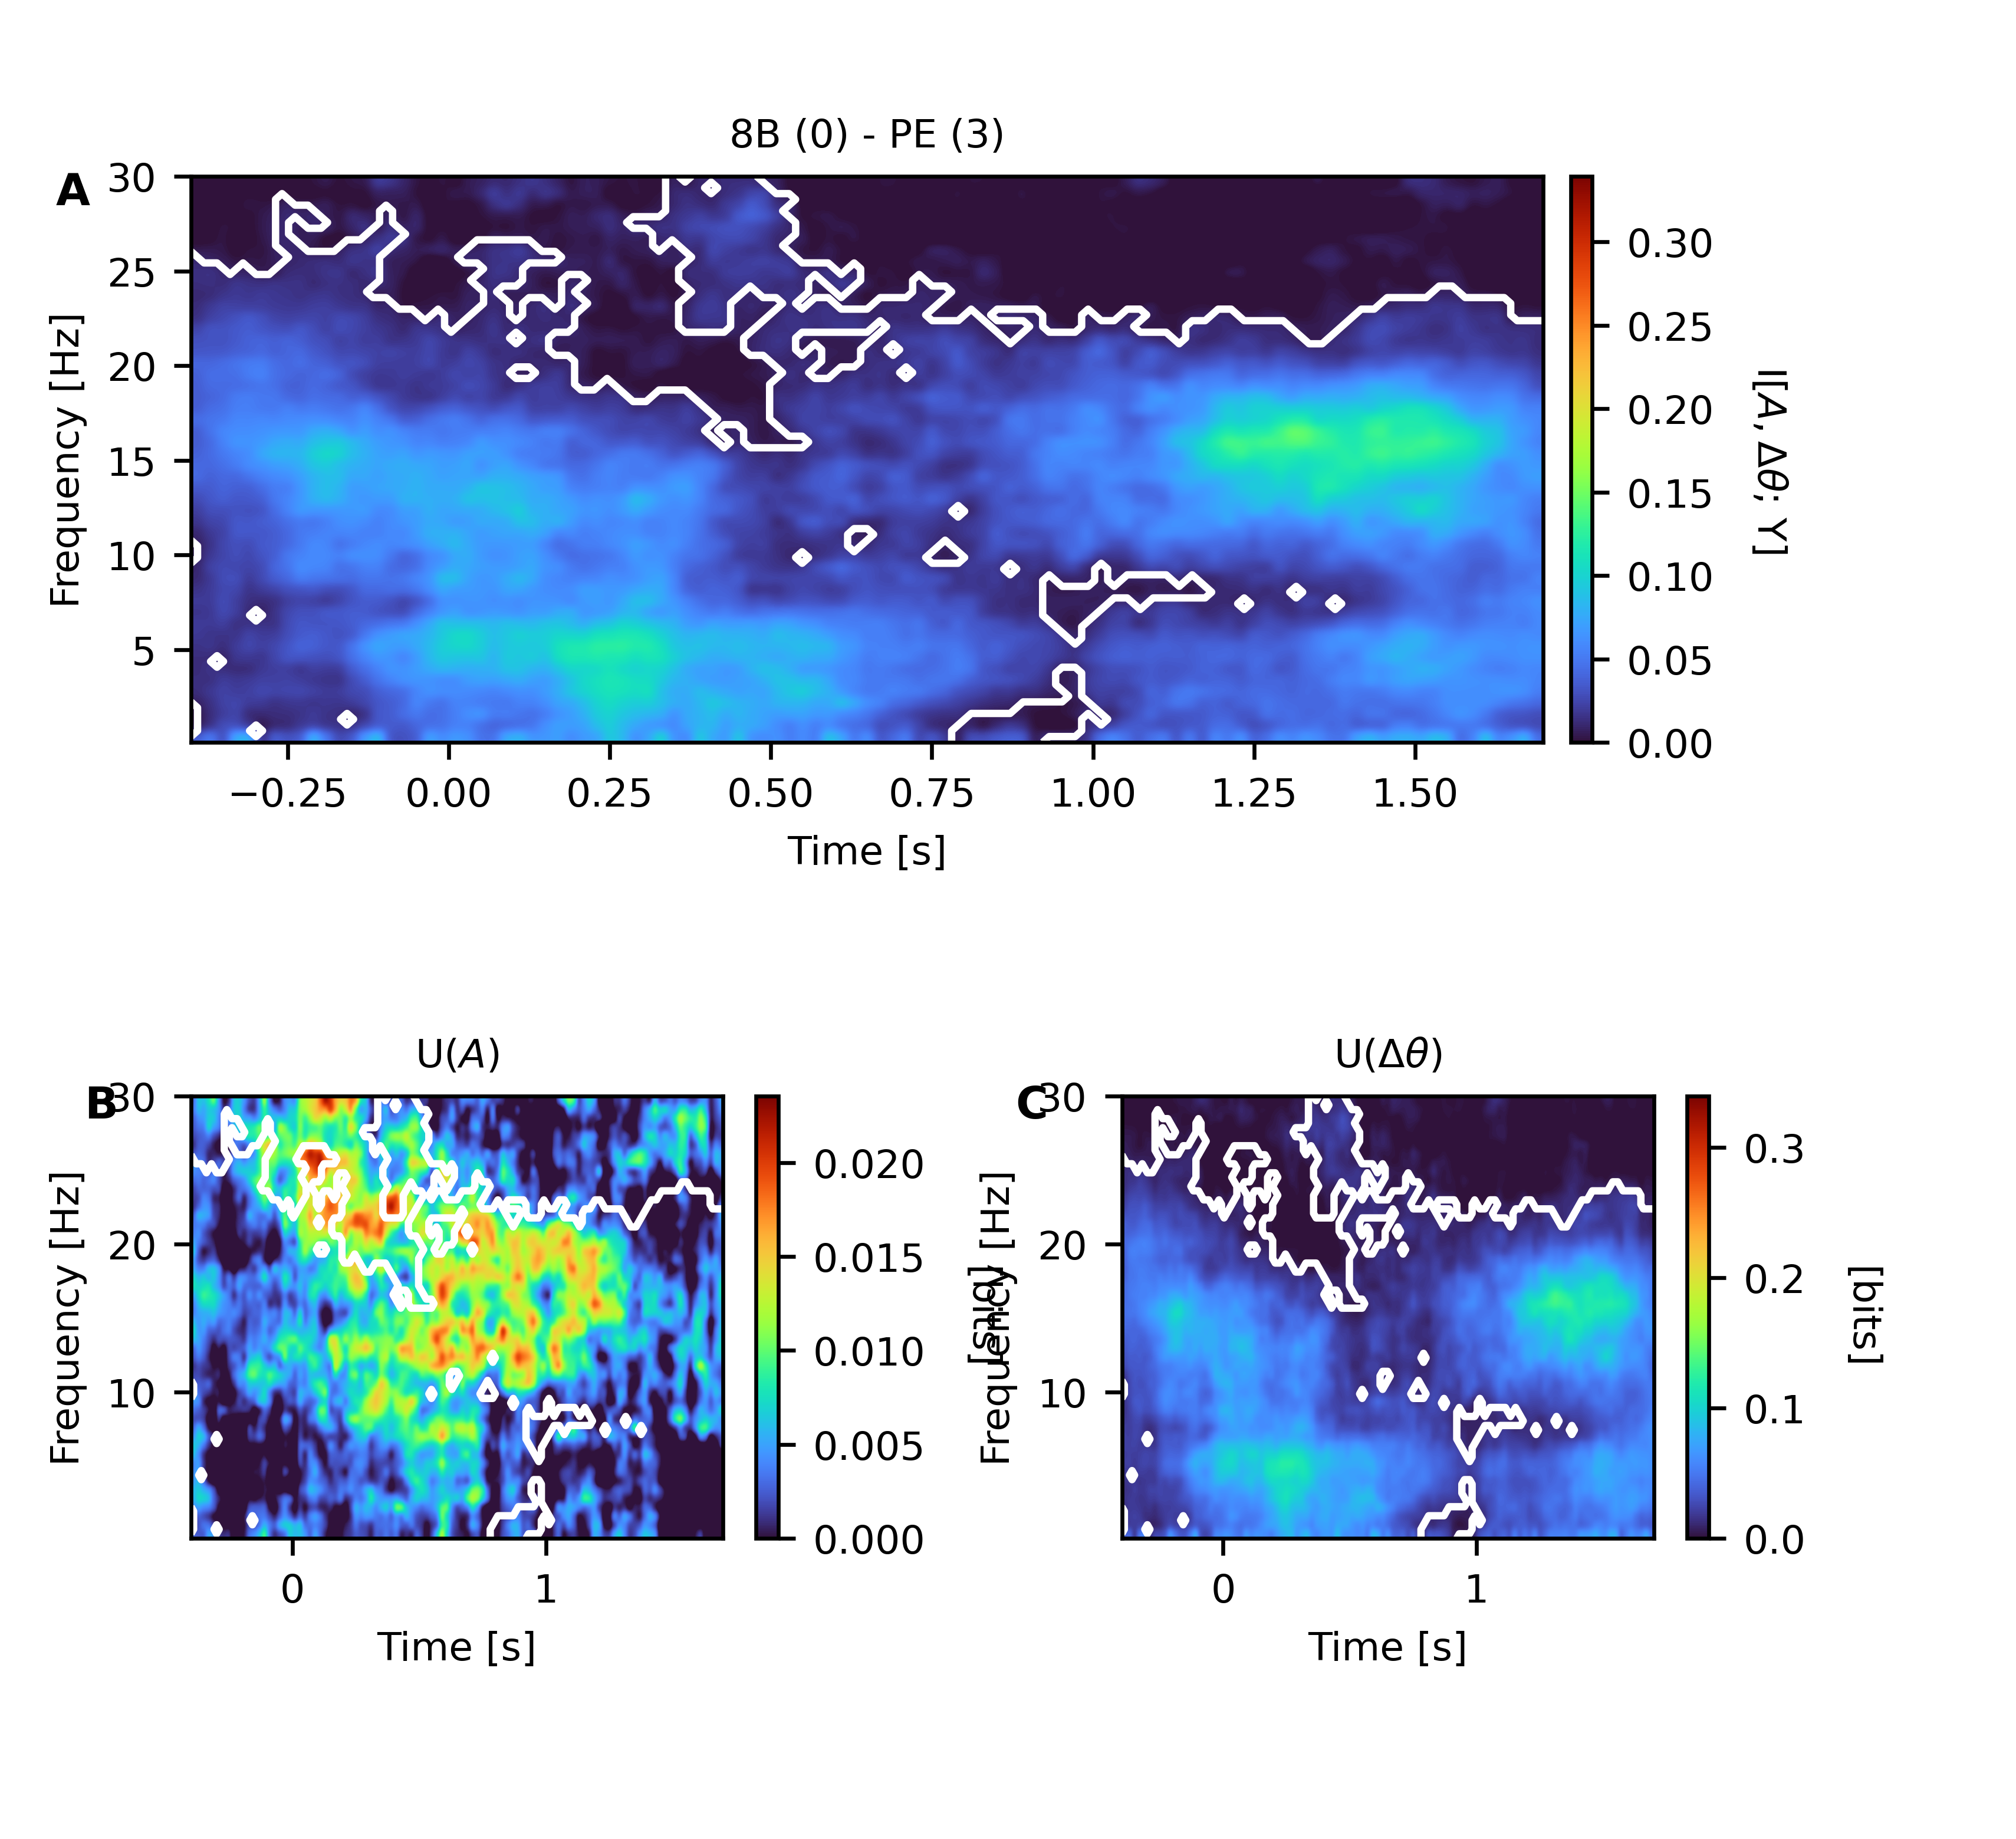

In [64]:
import plot
from PIL import Image

pos = 2

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.8,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.95, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2[pos],
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label(r"I[$A, \Delta\theta$; Y]", rotation=270, labelpad=15)

plt.contour(
    (p[..., pos].squeeze() <= 0.001),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

plt.sca(ax2)
plt.imshow(
    (I_S_R1[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    #vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p[..., pos].squeeze() <= 0.001),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


plt.title(r"U($A$)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
cbar.set_label("[bits]", rotation=270, labelpad=15)

plt.sca(ax3)

plt.imshow(
    (I_S_R2[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=I_S_R1_R2.max() / 1.5,
)
cbar = plt.colorbar()

plt.title(r"U($\Delta\theta$)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("[bits]", rotation=270, labelpad=15)
plt.contour(
    (p[..., pos].squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-.1] + [-0.2] * 2,
    ypos=[0.95] * 3,
)

plt.savefig("../Figures/Figure5.pdf")

Figure 5: Phase- and amplitude encoding in fronto-parietal recordings during working memory. A
Stimulus-related coherence given by the total mutual-information between phase- and amplitude about
the stimulus (Eq. 3) for a fronto-parietal channel pair (8B - PE). B,C Unique information about the stimulus
contained in the joint amplitude and phase-difference components of the signal. Areas delimited by the
white line correspond to significant effects obtained via shuffling surrogates (n = 1000; p < 0.05; corrected
using cluster statistics).

In [53]:
i, j = 2, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh1 = np.abs(Sxy) ** 2 / (Sxx * Syy)

i, j = 0, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh2 = np.abs(Sxy) ** 2 / (Sxx * Syy)

#### 7) Higher-order interaction across channel pairs — Figure 6

Compute the frequency-averaged cross-spectrum for two specific edge pairs (channels 0–1 and 2–3). Estimate joint MI and its redundancy/synergy decomposition; build a cluster-corrected null distribution (200 permutations).

In [ ]:

# Frequency-averaged cross-spectrum for each HOI edge pair
# Edge 1: channels 0–1 (parietal pair PG-PE); amplitude only → shape (1, ntrials, n_times)
z = (W[:, 0] * np.conj(W[:, 1])).mean(1)
dphi1 = np.abs(z)[None]

# Edge 2: channels 2–3 (fronto-parietal pair 8B-PE)
z = (W[:, 2] * np.conj(W[:, 3])).mean(1)
dphi2 = np.abs(z)[None]

# Joint representation of both edges: (2, ntrials, n_times)
mv = np.concatenate((dphi1, dphi2))

# Pairwise MI for each edge independently
I_S_R1_hoi = gcmi_model_nd_cd(
    dphi1, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

I_S_R2_hoi = gcmi_model_nd_cd(
    dphi2, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

# Joint MI across both edges
I_S_R1_R2_hoi = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)


In [55]:
# run in parallel
I_S_R1_R2_hoi_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(2_00))
)

100%|█████████████████████████████████| 200/200 [00:35<00:00,  5.70it/s]


In [57]:
p_hoi, t = wf.fit(
    [np.asarray(I_S_R1_R2_hoi[None])],
    [np.stack(I_S_R1_R2_hoi_shuffle)[:, None]],
    inference="ffx",
    mcp="cluster",
)

p_hoi = p_hoi.squeeze()

p_hoi.min()

    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.00913140670838699; tail=1)


0.005

In [ ]:

# HOI PID: same min-redundancy / max-synergy definitions as pairwise case
red = np.minimum(I_S_R1_hoi, I_S_R2_hoi)
syn = I_S_R1_R2_hoi - np.maximum(I_S_R2_hoi, I_S_R1_hoi)


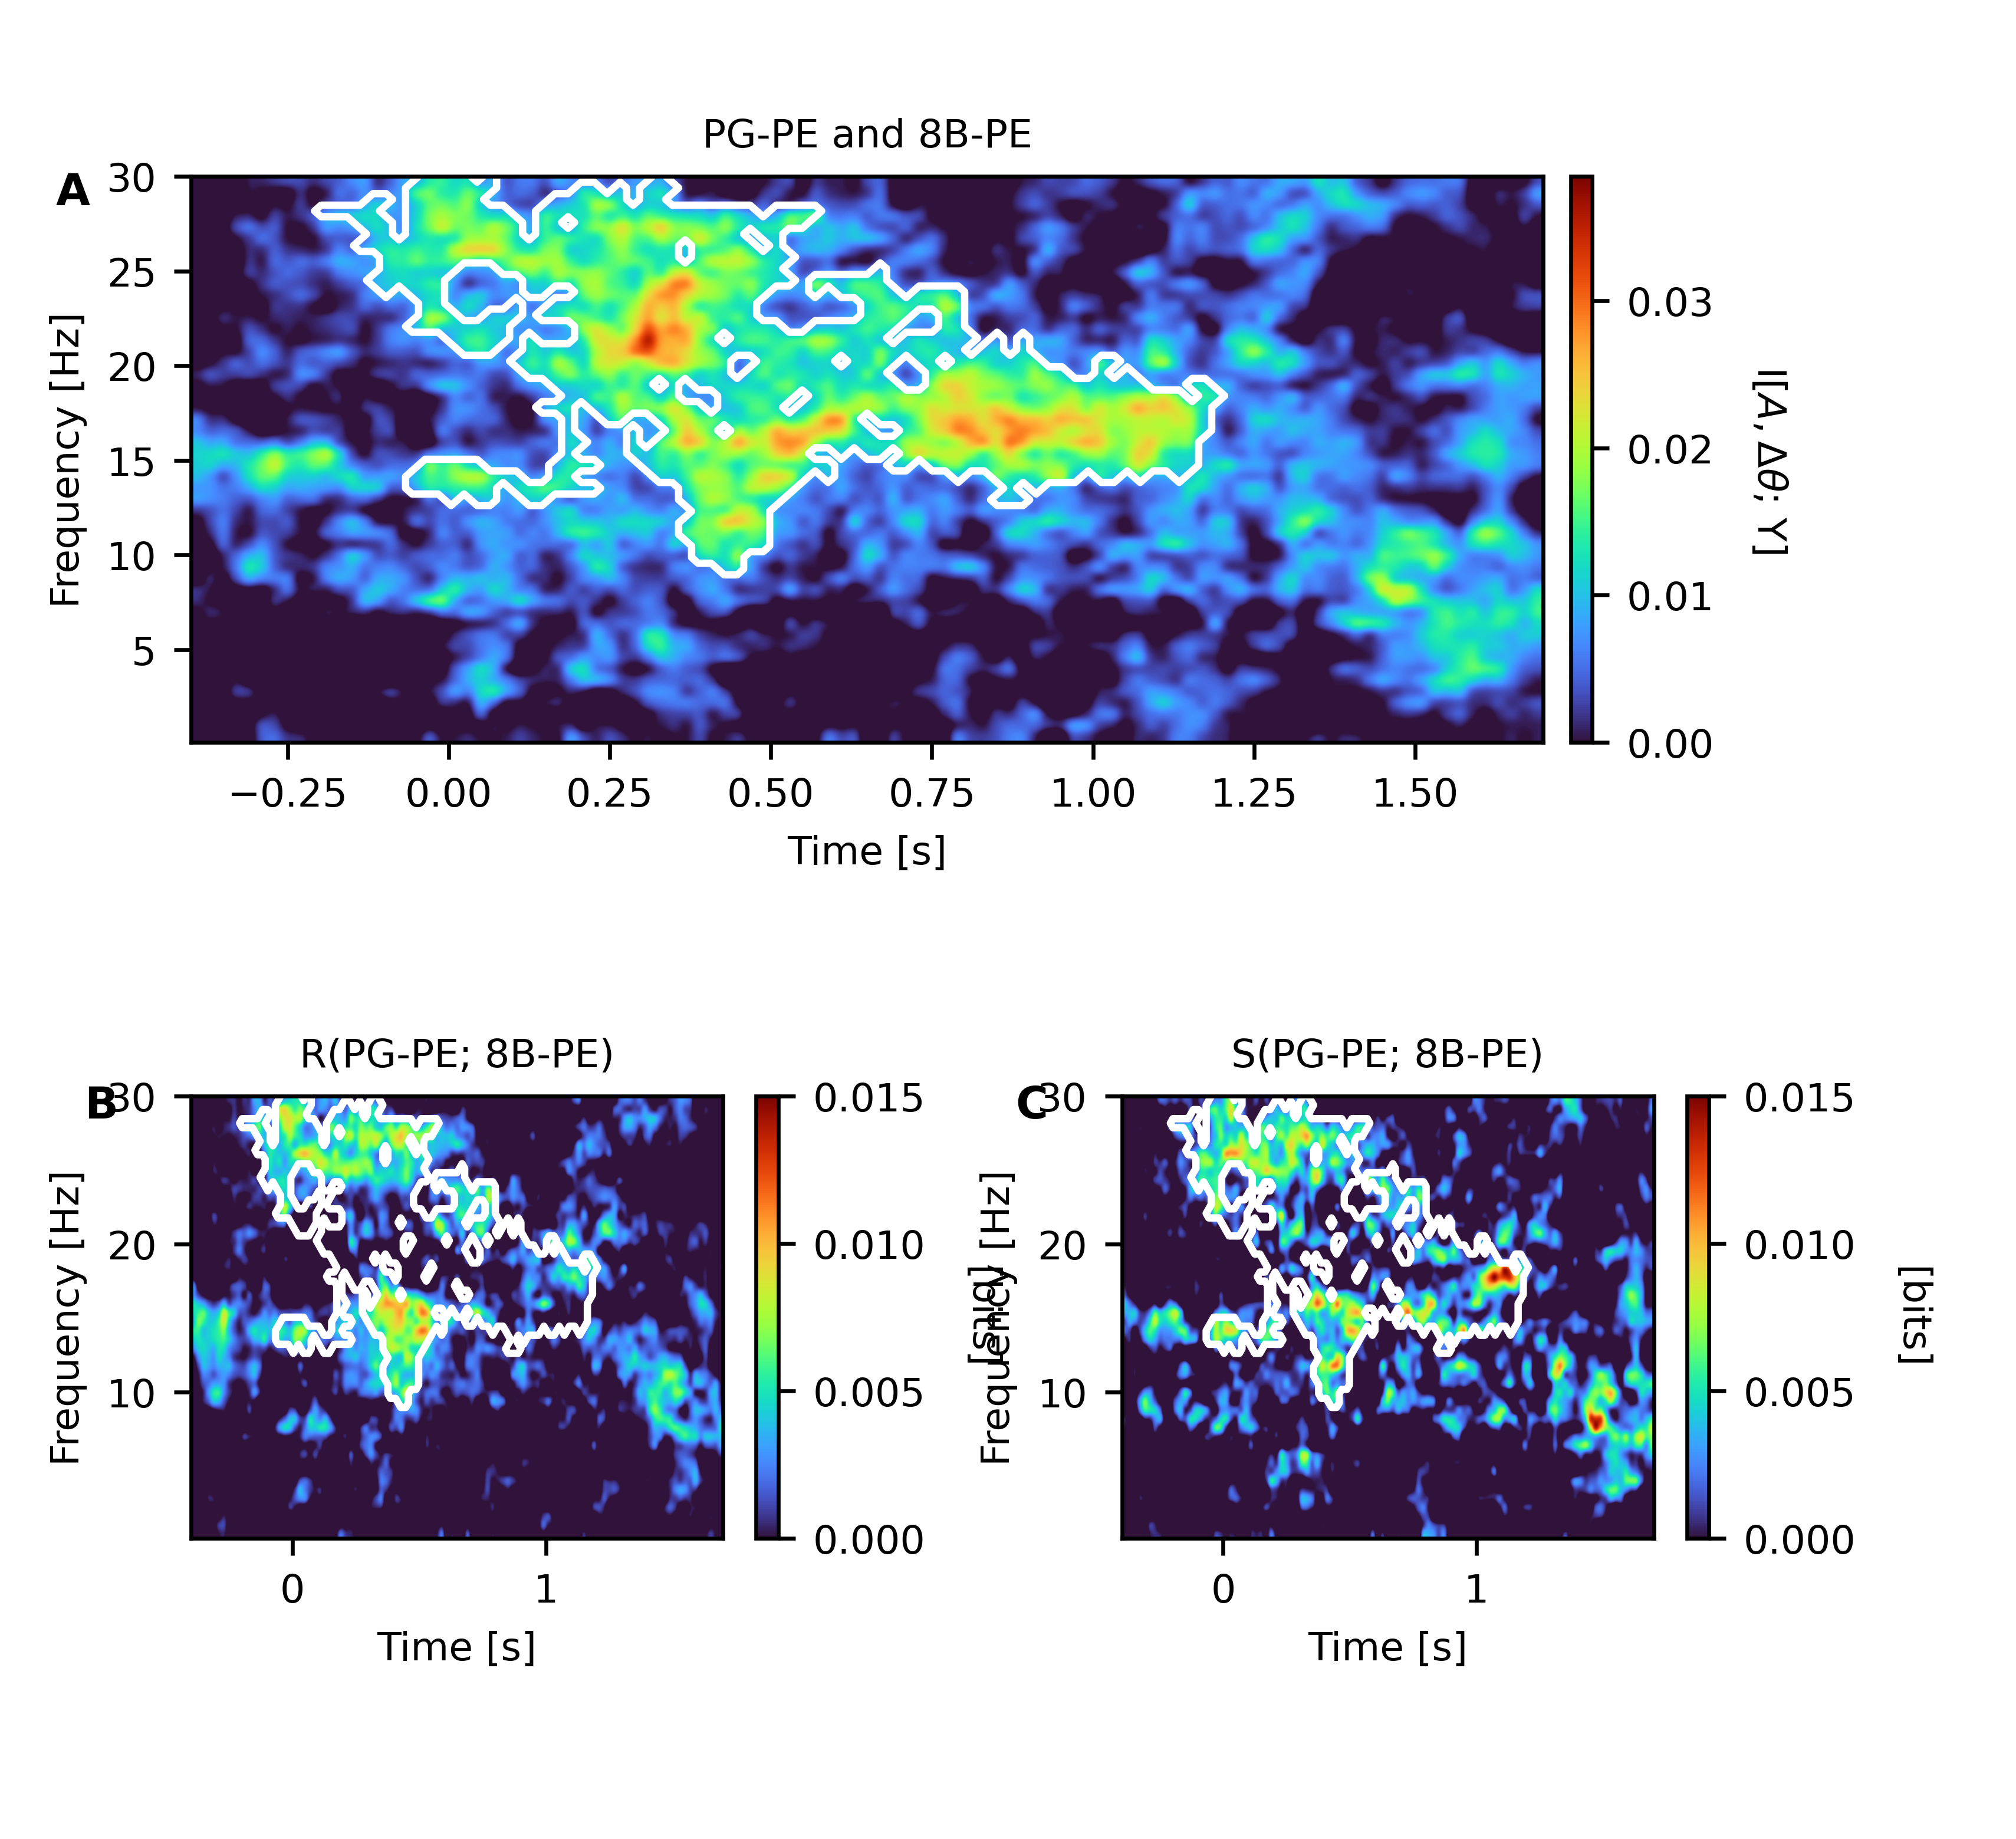

In [60]:
import plot
from PIL import Image

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.8,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.95, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2_hoi,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    #vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label(r"I[$A, \Delta\theta$; Y]", rotation=270, labelpad=15)

plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(f"PG-PE and 8B-PE")

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

plt.sca(ax2)
plt.imshow(
    red,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=.015,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


plt.title(r"R(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
cbar.set_label("[bits]", rotation=270, labelpad=15)

plt.sca(ax3)

plt.imshow(
    syn,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=.015,
)
cbar = plt.colorbar()

plt.title(r"S(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("[bits]", rotation=270, labelpad=15)
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-.1] + [-0.2] * 2,
    ypos=[0.95] * 3,
)

plt.savefig("../Figures/Figure6.pdf")

Figure 6: High-order phase- and amplitude encoding during working memory. (A) Stimulus-related
coherence given by the total mutual-information between phase- and amplitude edges for parietal-parietal
channel pair PG-PE and fronto-parietal channel pair 8B-PE about the stimulus (Eq. 3). The amplitude-phase
edge for each channel pair is given by Eqs. 10. (B) High-order redundant information about the stimulus
contained in the joint amplitude and phase-difference components of the signal. Areas delimited by the
white line correspond to significant effects obtained via shuffling surrogates (n = 1000; p < 0.05; corrected
using cluster statistics). (C) The same as (B) but showing the high-order synergistic information.